In [2]:
import pandas as pd

df = pd.read_csv("data/SampleSuperstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [6]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Orders: 5009


In [7]:
print(df["Category"].unique())

<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str


In [8]:
print(df["Region"].unique())

<StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str


In [9]:
category_analysis = (
    df.groupby("Category")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

category_analysis.round(2)

,Sales,Profit
Category,,
Technology,836154.03,145454.95
Furniture,741999.80,18451.27
Office Supplies,719047.03,122490.80


In [10]:
df.groupby("Category")["Sales"].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

In [11]:
category_analysis = (
    df.groupby("Category")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

category_analysis.round(2)

,Sales,Profit
Category,,
Technology,836154.03,145454.95
Furniture,741999.80,18451.27
Office Supplies,719047.03,122490.80


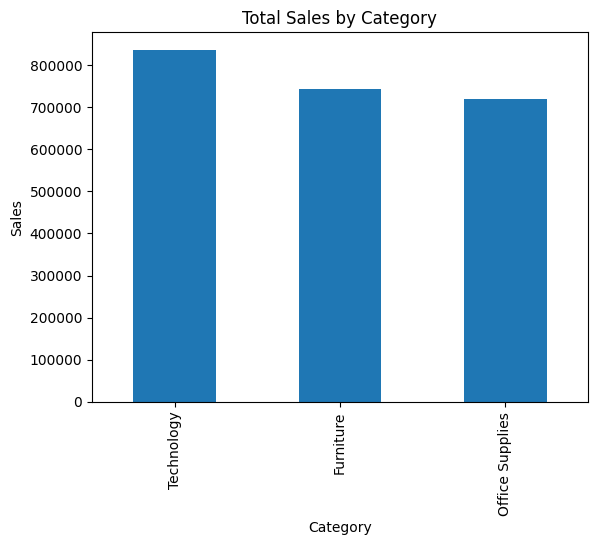

In [12]:
import matplotlib.pyplot as plt

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

In [13]:
region_analysis = (
    df.groupby("Region")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

region_analysis.round(2)

,Sales,Profit
Region,,
West,725457.82,108418.45
East,678781.24,91522.78
Central,501239.89,39706.36
South,391721.90,46749.43


In [14]:
subcategory_analysis = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
      .sum()
      .sort_values("Profit", ascending=False)
)

subcategory_analysis.round(2)

,Sales,Profit
Sub-Category,,
Copiers,149528.03,55617.82
Phones,330007.05,44515.73
Accessories,167380.32,41936.64
Paper,78479.21,34053.57
Binders,203412.73,30221.76
Chairs,328449.10,26590.17
Storage,223843.61,21278.83
Appliances,107532.16,18138.01
Furnishings,91705.16,13059.14


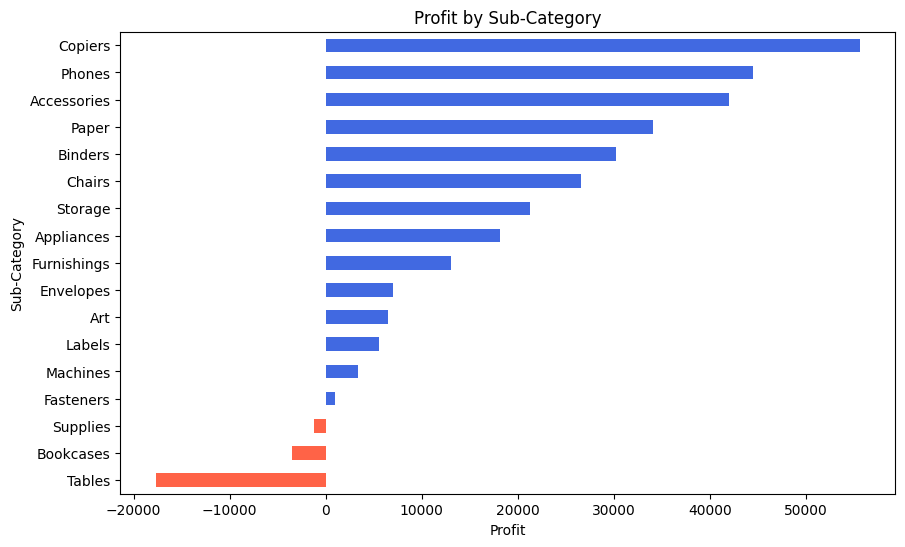

In [17]:
import matplotlib.pyplot as plt

sub_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()

colors = ["tomato" if value < 0 else "royalblue" for value in sub_profit]

sub_profit.plot(kind="barh", color=colors, figsize=(10,6))

plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")
plt.show()

Top 10 Products by Sales

In [23]:
top_sales_products = (
    df.groupby(["Product Name","Sub-Category"])["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_sales_products

Product Name                                                                 Sub-Category
Canon imageCLASS 2200 Advanced Copier                                        Copiers         61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind  Binders         27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                        Machines        22638.480
HON 5400 Series Task Chairs for Big and Tall                                 Chairs          21870.576
GBC DocuBind TL300 Electric Binding System                                   Binders         19823.479
GBC Ibimaster 500 Manual ProClick Binding System                             Binders         19024.500
Hewlett Packard LaserJet 3310 Copier                                         Copiers         18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                    Machines        18374.895
GBC DocuBind P400 Electric Binding System                                    Binders  

Top 10 Products by Profit

In [24]:
top_profit_products = (
    df.groupby(["Product Name","Sub-Category"])["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_profit_products

Product Name                                                                 Sub-Category
Canon imageCLASS 2200 Advanced Copier                                        Copiers         25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind  Binders          7753.0390
Hewlett Packard LaserJet 3310 Copier                                         Copiers          6983.8836
Canon PC1060 Personal Laser Copier                                           Copiers          4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                    Machines         4094.9766
Ativa V4110MDD Micro-Cut Shredder                                            Machines         3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                             Machines         3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                   Accessories      3696.2820
Ibico EPK-21 Electric Binding System                                         B

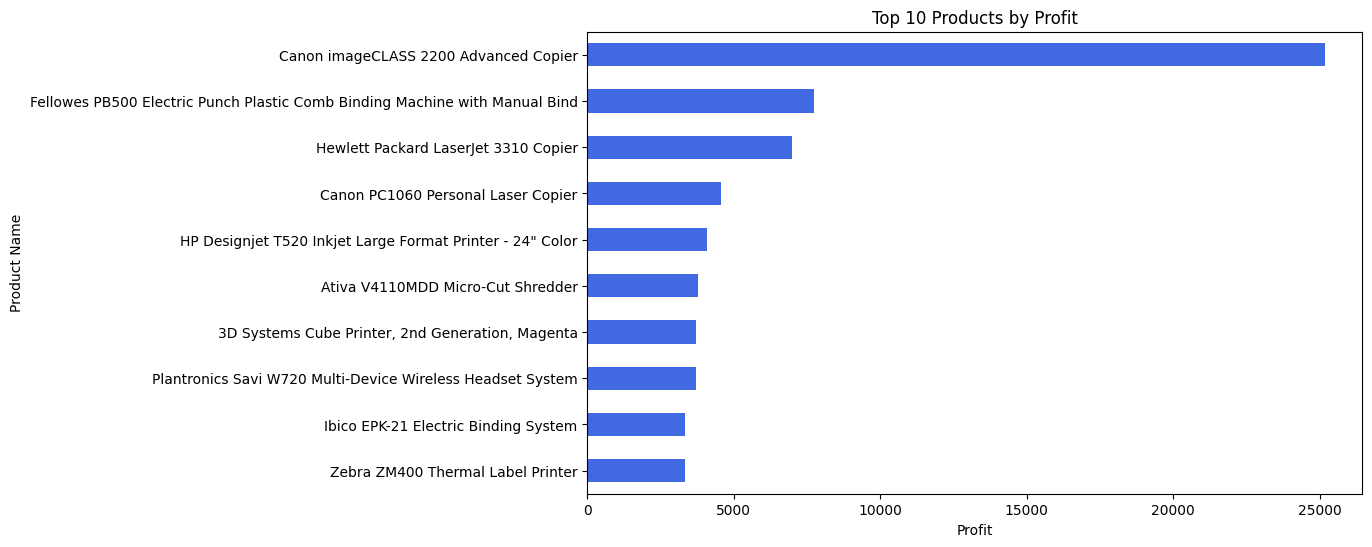

In [21]:
top_profit_products.sort_values().plot(
    kind="barh",
    figsize=(10,6),
    color=["royalblue" if x > 0 else "red" for x in top_profit_products.sort_values()]
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")
plt.show()